# Experiment 2 — Resolution Degradation Curves

**Objective:** Run the model selected in Experiment 1 at six resolutions
(640 → 320 in 64-pixel steps) on all three MOT17 sequences.
Compute two primary degradation signals relative to the 640 baseline and plot per-sequence curves.

**Sequences:** MOT17-09 (sparse, pedestrian street, 10.1 ped/fr, low angle),
MOT17-02 (moderate, open square, 31.0 ped/fr, moderate elevation), and
MOT17-04 (dense, pedestrian street at night, 45.3 ped/fr, elevated viewpoint).
Sequences differ in both pedestrian density and camera elevation; these cannot be fully
decoupled within the available MOT17 static-camera sequences.

**Two primary degradation signals (methodology v3):**
1. Identity confusion — IDSW normalised by GT track count (`idsw_per_gt_track`), with ±1-switch noise floor shading
2. End-to-end track continuity — Mostly Tracked ratio (`mostly_tracked_ratio`)

Both signals must be co-plotted in every panel. In dense scenes at low resolution, detection
recall collapse suppresses the association pool and drives raw IDSW counts toward zero even as
`mt_delta_norm` indicates most tracks are lost. Presenting only IDSW would misrepresent the
failure mode as improvement.

Track fragmentation (`frag_ratio`), detection stability, and spatial precision are computed
separately as diagnostic data. They are not primary claims — see methodology v3 for rationale.

In [1]:
# ── Configuration ─────────────────────────────────────────────────────────────
import torch
from benchmark.config import (
    DATA_ROOT, RESULTS_RAW, SEQUENCES, SEQ_SUFFIX,
    RESOLUTIONS, IMGSZ_BASE, MODEL_VARIANTS,
)

DEVICE        = "cuda:0" if torch.cuda.is_available() else "cpu"
SKIP_EXISTING = True  # Skip evaluation if output CSV already exists (per model, per resolution)

# CLAHE luminance normalisation: applied uniformly across ALL sequences and ALL
# resolutions when True. Parameters are fixed in runner.py (clip=2.0, grid=8×8).
# Produces _clahe-suffixed CSVs; baseline results are untouched.
USE_CLAHE = False

clahe_tag = "_clahe" if USE_CLAHE else ""

print(f"Models      : {MODEL_VARIANTS}")
print(f"Sequences   : {SEQUENCES}")
print(f"Resolutions : {RESOLUTIONS}")
print(f"Device      : {DEVICE}")
print(f"CLAHE       : {USE_CLAHE}")

Models      : ['yolo26n.pt', 'yolo26s.pt', 'yolo26m.pt', 'yolo26l.pt', 'yolo26x.pt']
Sequences   : ['MOT17-09', 'MOT17-02', 'MOT17-04']
Resolutions : [640, 576, 512, 448, 384, 320]
Device      : cuda:0
CLAHE       : False


In [2]:
# Inference loop: 3 models × 6 resolutions × 3 sequences
# CSVs written by notebook 01 are reused when present (skip guard).
from ultralytics import YOLO
from benchmark.runner import run_sequence

for model_path in MODEL_VARIANTS:
    print(f"\n── Model: {model_path} ──")
    for imgsz in RESOLUTIONS:
        for seq_name in SEQUENCES:
            out_csv = RESULTS_RAW / f"{seq_name}_{model_path}_{imgsz}{clahe_tag}.csv"
            if SKIP_EXISTING and out_csv.exists():
                print(f"  {seq_name} @ {imgsz}px: skip")
                continue

            seq_dir = DATA_ROOT / f"{seq_name}-{SEQ_SUFFIX}"
            # Fresh model instance per (model, resolution, sequence) to reset ByteTrack state.
            # .to(DEVICE) places the model on the target device before inference.
            model = YOLO(model_path).to(DEVICE)
            print(f"  {seq_name} @ {imgsz}px: running ...", end=" ", flush=True)
            df = run_sequence(model, seq_dir, imgsz=imgsz, out_csv=out_csv, clahe=USE_CLAHE)
            print(f"done — mean {df['n_detections'].mean():.1f} det/frame")


── Model: yolo26n.pt ──
  MOT17-09 @ 640px: skip
  MOT17-02 @ 640px: skip
  MOT17-04 @ 640px: skip
  MOT17-09 @ 576px: skip
  MOT17-02 @ 576px: skip
  MOT17-04 @ 576px: skip
  MOT17-09 @ 512px: skip
  MOT17-02 @ 512px: skip
  MOT17-04 @ 512px: skip
  MOT17-09 @ 448px: skip
  MOT17-02 @ 448px: skip
  MOT17-04 @ 448px: skip
  MOT17-09 @ 384px: skip
  MOT17-02 @ 384px: skip
  MOT17-04 @ 384px: skip
  MOT17-09 @ 320px: skip
  MOT17-02 @ 320px: skip
  MOT17-04 @ 320px: skip

── Model: yolo26s.pt ──
  MOT17-09 @ 640px: skip
  MOT17-02 @ 640px: skip
  MOT17-04 @ 640px: skip
  MOT17-09 @ 576px: skip
  MOT17-02 @ 576px: skip
  MOT17-04 @ 576px: skip
  MOT17-09 @ 512px: skip
  MOT17-02 @ 512px: skip
  MOT17-04 @ 512px: skip
  MOT17-09 @ 448px: skip
  MOT17-02 @ 448px: skip
  MOT17-04 @ 448px: skip
  MOT17-09 @ 384px: skip
  MOT17-02 @ 384px: skip
  MOT17-04 @ 384px: skip
  MOT17-09 @ 320px: skip
  MOT17-02 @ 320px: skip
  MOT17-04 @ 320px: skip

── Model: yolo26m.pt ──
  MOT17-09 @ 640px: skip


In [3]:
# ── Primary signal computation ─────────────────────────────────────────────────
#
# For each (model, sequence, resolution): load the CSV and compute the two primary
# track-continuity signals via track_continuity(). Fragmentation diagnostic
# columns are stored alongside the primary signals but are not plotted.
import pandas as pd
from benchmark.degradation import track_continuity

deg_rows = []

for model_path in MODEL_VARIANTS:
    for seq_name in SEQUENCES:
        baseline_csv = RESULTS_RAW / f"{seq_name}_{model_path}_{IMGSZ_BASE}{clahe_tag}.csv"
        seq_dir      = DATA_ROOT / f"{seq_name}-{SEQ_SUFFIX}"

        if not baseline_csv.exists():
            print(f"WARNING: baseline CSV missing for {model_path} / {seq_name}, skip")
            continue

        for imgsz in RESOLUTIONS:
            csv_path = RESULTS_RAW / f"{seq_name}_{model_path}_{imgsz}{clahe_tag}.csv"
            if not csv_path.exists():
                continue

            tc = track_continuity(csv_path, seq_dir)
            deg_rows.append({
                "model":                model_path,
                "seq":                  seq_name,
                "imgsz":                imgsz,
                "num_switches":         tc["num_switches"],
                "idsw_per_gt_track":    tc["idsw_per_gt_track"],
                "mostly_tracked_ratio": tc["mostly_tracked_ratio"],
                # Fragmentation — diagnostic only, not a primary signal
                "frag_ratio":           tc["frag_ratio"],
                "short_tracks_abs":     tc["short_tracks_abs"],
                "total_initiated":      tc["total_initiated"],
            })

deg_df = pd.DataFrame(deg_rows)

print("Primary signals — absolute values:")
print(deg_df[["model", "seq", "imgsz", "num_switches", "idsw_per_gt_track",
              "mostly_tracked_ratio"]].to_string(index=False))

Primary signals — absolute values:
     model      seq  imgsz  num_switches  idsw_per_gt_track  mostly_tracked_ratio
yolo26n.pt MOT17-09    640            47           1.807692              0.615385
yolo26n.pt MOT17-09    576            50           1.923077              0.615385
yolo26n.pt MOT17-09    512            52           2.000000              0.615385
yolo26n.pt MOT17-09    448            70           2.692308              0.500000
yolo26n.pt MOT17-09    384            68           2.615385              0.384615
yolo26n.pt MOT17-09    320            68           2.615385              0.346154
yolo26n.pt MOT17-02    640            45           0.849057              0.207547
yolo26n.pt MOT17-02    576            31           0.584906              0.188679
yolo26n.pt MOT17-02    512            37           0.698113              0.150943
yolo26n.pt MOT17-02    448            41           0.773585              0.150943
yolo26n.pt MOT17-02    384            52           0.981132    

In [4]:
# ── Diagnostic signals ─────────────────────────────────────────────────────────
#
# Detection stability, spatial precision, and fragmentation denominator data.
# These are not primary claims and are not plotted in the paper figure.
#
# - det_stability: mean absolute deviation of per-frame detection count vs the
#   640 baseline. Noisy proxy for recall (conflates TP and FP count changes).
# - spatial_prec: mean footpoint displacement vs 640 baseline (pixels).
#   No stable trend distinct from the primary signals was observed.
# - Fragmentation denominator: short_tracks_abs (0–14 events per condition) is
#   too sparse to trend. Retained here to confirm denominator stability.
from benchmark.degradation import detection_stability, spatial_precision

for model_path in MODEL_VARIANTS:
    for seq_name in SEQUENCES:
        baseline_csv = RESULTS_RAW / f"{seq_name}_{model_path}_{IMGSZ_BASE}{clahe_tag}.csv"
        if not baseline_csv.exists():
            continue
        for imgsz in RESOLUTIONS:
            csv_path = RESULTS_RAW / f"{seq_name}_{model_path}_{imgsz}{clahe_tag}.csv"
            if not csv_path.exists():
                continue
            mask = (
                (deg_df["model"] == model_path) &
                (deg_df["seq"]   == seq_name) &
                (deg_df["imgsz"] == imgsz)
            )
            deg_df.loc[mask, "det_stability"] = detection_stability(csv_path, baseline_csv)
            deg_df.loc[mask, "spatial_prec"]  = spatial_precision(csv_path, baseline_csv)

print("Fragmentation denominator diagnostics:")
print(deg_df[["model", "seq", "imgsz", "frag_ratio", "short_tracks_abs",
              "total_initiated"]].to_string(index=False))

Fragmentation denominator diagnostics:
     model      seq  imgsz  frag_ratio  short_tracks_abs  total_initiated
yolo26n.pt MOT17-09    640    0.115385                 3               74
yolo26n.pt MOT17-09    576    0.076923                 2               78
yolo26n.pt MOT17-09    512    0.038462                 1               83
yolo26n.pt MOT17-09    448    0.230769                 6               88
yolo26n.pt MOT17-09    384    0.269231                 7               78
yolo26n.pt MOT17-09    320    0.230769                 6               77
yolo26n.pt MOT17-02    640    0.075472                 4               94
yolo26n.pt MOT17-02    576    0.075472                 4               93
yolo26n.pt MOT17-02    512    0.132075                 7               82
yolo26n.pt MOT17-02    448    0.132075                 7               79
yolo26n.pt MOT17-02    384    0.018868                 1               77
yolo26n.pt MOT17-02    320    0.018868                 1               51

In [5]:
# ── Per-(model, sequence) normalisation anchored at 640 baseline ───────────────
#
# Two primary signals:
# 1. idsw_per_gt_track — identity confusion (positive = more switches = worse)
# 2. mostly_tracked_ratio — end-to-end continuity (inverted so positive = worse)
#
# Noise floor for IDSW: a change of ±1 raw switch, expressed as a fraction of the
# 640 baseline idsw_per_gt_track, defines the minimum detectable effect size given
# the small GT track counts (MOT17-09: 26 tracks, MOT17-02: 53, MOT17-04: 79).
# Changes within this band should not be interpreted as meaningful trends.
import numpy as np
from benchmark.mot_gt import load_gt

n_gt_by_seq = {
    seq: load_gt(DATA_ROOT / f"{seq}-{SEQ_SUFFIX}")["track_id"].nunique()
    for seq in SEQUENCES
}

for model_path in MODEL_VARIANTS:
    for seq_name in SEQUENCES:
        mask     = (deg_df["model"] == model_path) & (deg_df["seq"] == seq_name)
        baseline = deg_df[mask & (deg_df["imgsz"] == IMGSZ_BASE)]
        if baseline.empty:
            continue

        base_idsw = float(baseline["idsw_per_gt_track"].iloc[0])
        base_mt   = float(baseline["mostly_tracked_ratio"].iloc[0])
        n_gt      = n_gt_by_seq[seq_name]

        # IDSW relative change from 640 baseline (0 = baseline, positive = more confusion)
        deg_df.loc[mask, "idsw_delta_norm"] = (
            (deg_df.loc[mask, "idsw_per_gt_track"] - base_idsw) / base_idsw
        ).clip(-1, None) if base_idsw > 0 else 0.0

        # ±1-switch noise floor expressed as fraction of baseline idsw_per_gt_track.
        # A ±1 raw switch = ±(1/n_gt) in idsw_per_gt_track units.
        # Normalised to baseline: noise_band = (1/n_gt) / base_idsw
        deg_df.loc[mask, "idsw_noise_band"] = (1.0 / n_gt) / base_idsw if base_idsw > 0 else 0.0

        # MT relative change: inverted so positive = degradation (fewer mostly-tracked)
        deg_df.loc[mask, "mt_delta_norm"] = (
            (base_mt - deg_df.loc[mask, "mostly_tracked_ratio"]) / base_mt
        ).clip(-1, None) if base_mt > 0 else 0.0

print("Primary signals (640 baseline = 0, positive = worse):")
print(deg_df[["model", "seq", "imgsz", "idsw_per_gt_track",
              "idsw_delta_norm", "idsw_noise_band", "mt_delta_norm"]].to_string(index=False))

Primary signals (640 baseline = 0, positive = worse):
     model      seq  imgsz  idsw_per_gt_track  idsw_delta_norm  idsw_noise_band  mt_delta_norm
yolo26n.pt MOT17-09    640           1.807692         0.000000         0.021277       0.000000
yolo26n.pt MOT17-09    576           1.923077         0.063830         0.021277       0.000000
yolo26n.pt MOT17-09    512           2.000000         0.106383         0.021277       0.000000
yolo26n.pt MOT17-09    448           2.692308         0.489362         0.021277       0.187500
yolo26n.pt MOT17-09    384           2.615385         0.446809         0.021277       0.375000
yolo26n.pt MOT17-09    320           2.615385         0.446809         0.021277       0.437500
yolo26n.pt MOT17-02    640           0.849057         0.000000         0.022222       0.000000
yolo26n.pt MOT17-02    576           0.584906        -0.311111         0.022222       0.090909
yolo26n.pt MOT17-02    512           0.698113        -0.177778         0.022222       0.272

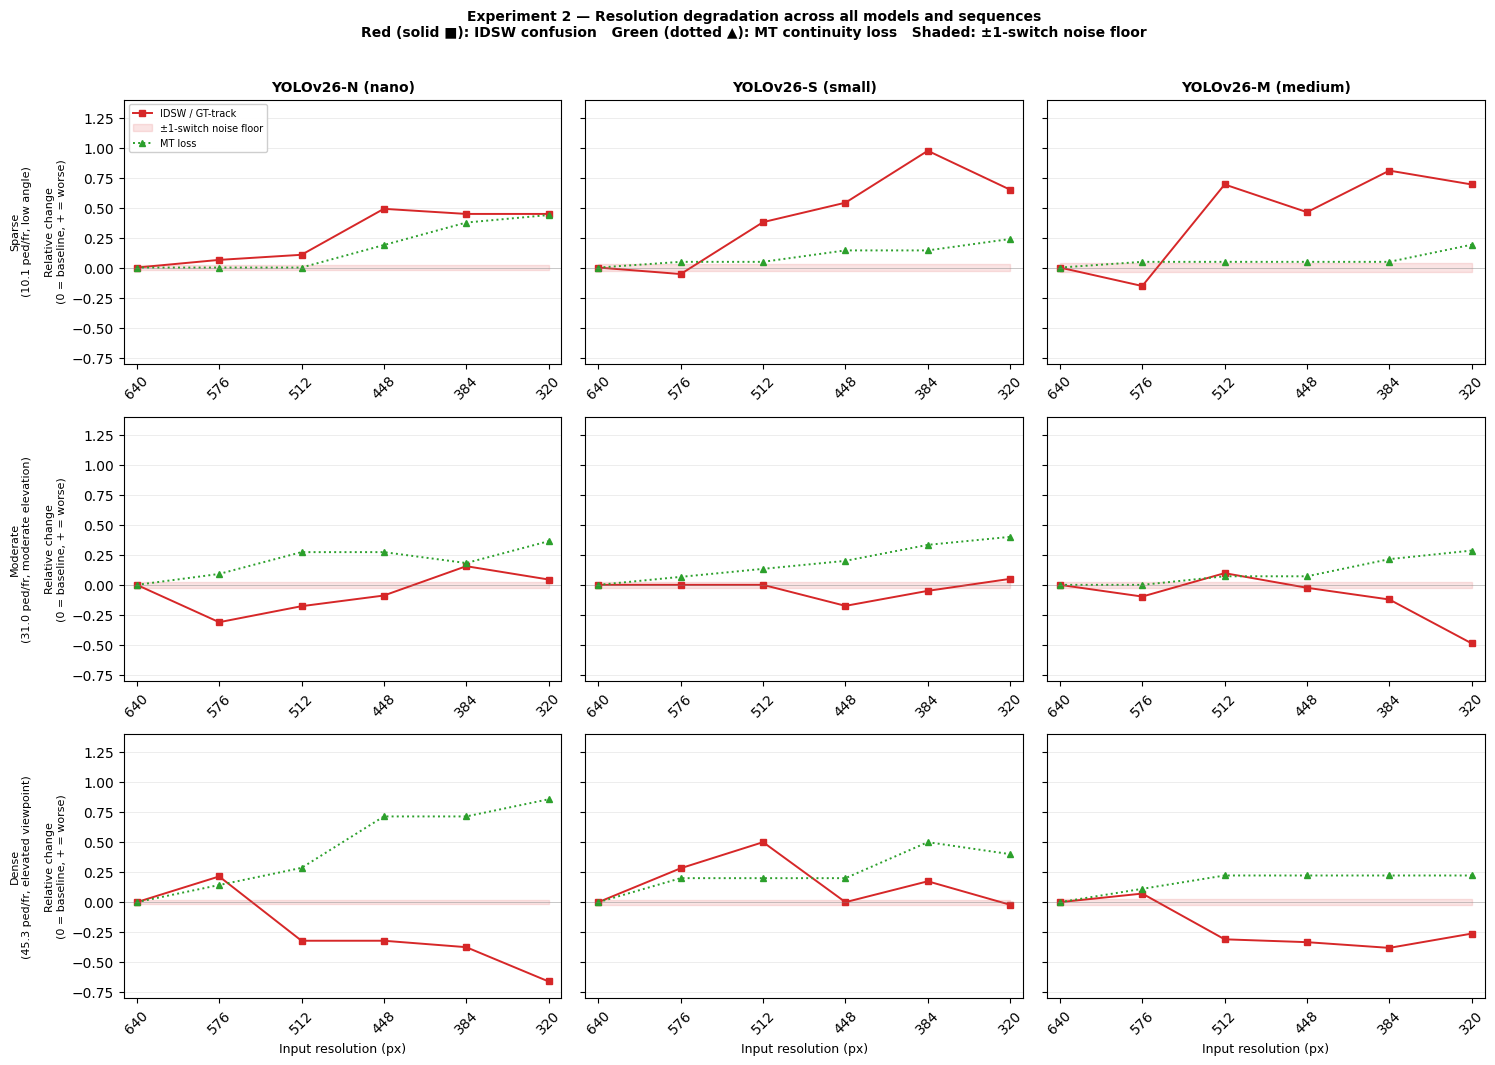

Saved → /home/joaocarlos/Developer/yolo26-track-edge-benchmark/results/figures/exp2_degradation_curves.pdf


In [6]:
# ── Two-signal degradation plot: IDSW (confusion) + MT (continuity) ───────────
#
# Layout: rows = sequences (sparse / moderate / dense), columns = model variants.
# Each panel shows relative change from the 640 baseline.
#   IDSW (red solid square)   — identity confusion; shaded band = ±1-switch noise floor
#   MT loss (green dotted ^)  — end-to-end track continuity loss (inverted: positive = worse)
#
# Both signals are co-plotted in every panel. In dense scenes at low resolution,
# IDSW can go negative (detection-pool suppression) while MT rises — presenting
# only IDSW would misrepresent the failure mode as improvement.

import matplotlib.pyplot as plt

SEQ_LABELS = {
    "MOT17-09": "Sparse\n(10.1 ped/fr, low angle)",
    "MOT17-02": "Moderate\n(31.0 ped/fr, moderate elevation)",
    "MOT17-04": "Dense\n(45.3 ped/fr, elevated viewpoint)",
}
MODEL_LABELS = {
    "yolo26n.pt": "YOLOv26-N (nano)",
    "yolo26s.pt": "YOLOv26-S (small)",
    "yolo26m.pt": "YOLOv26-M (medium)",
}
COLOR_IDSW = "#d62728"
COLOR_MT   = "#2ca02c"

n_rows = len(SEQUENCES)
n_cols = len(MODEL_VARIANTS)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), sharey=True)

for row_idx, seq_name in enumerate(SEQUENCES):
    for col_idx, model_path in enumerate(MODEL_VARIANTS):
        ax   = axes[row_idx, col_idx]
        mask = (deg_df["model"] == model_path) & (deg_df["seq"] == seq_name)
        sub  = deg_df[mask].sort_values("imgsz", ascending=False)
        if sub.empty:
            ax.set_visible(False)
            continue

        band = float(sub["idsw_noise_band"].iloc[0])

        ax.plot(sub["imgsz"], sub["idsw_delta_norm"], "s-", color=COLOR_IDSW,
                label="IDSW / GT-track", markersize=4, linewidth=1.4)
        ax.fill_between(sub["imgsz"], -band, band,
                        color=COLOR_IDSW, alpha=0.12, label="±1-switch noise floor")
        ax.plot(sub["imgsz"], sub["mt_delta_norm"], "^:", color=COLOR_MT,
                label="MT loss", markersize=4, linewidth=1.4)

        ax.axhline(0, color="grey", linewidth=0.6, alpha=0.4)
        ax.set_xlim(650, 310)
        ax.set_xticks(RESOLUTIONS)
        ax.tick_params(axis="x", rotation=45)
        ax.grid(axis="y", linewidth=0.4, alpha=0.4)
        ax.set_ylim(-0.8, 1.4)

        if row_idx == 0:
            ax.set_title(MODEL_LABELS.get(model_path, model_path),
                         fontsize=10, fontweight="bold")
        if col_idx == 0:
            ax.set_ylabel(
                f"{SEQ_LABELS[seq_name]}\n\nRelative change\n(0 = baseline, + = worse)",
                fontsize=8,
            )
        if row_idx == n_rows - 1:
            ax.set_xlabel("Input resolution (px)", fontsize=9)
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7, loc="upper left", framealpha=0.95)

fig.suptitle(
    "Experiment 2 — Resolution degradation across all models and sequences\n"
    "Red (solid ■): IDSW confusion   Green (dotted ▲): MT continuity loss   "
    "Shaded: ±1-switch noise floor",
    fontsize=10, fontweight="bold", y=1.01,
)
plt.tight_layout()
out_path = RESULTS_RAW.parent / "figures" / "exp2_degradation_curves.pdf"
plt.savefig(out_path, bbox_inches="tight", dpi=150)
plt.show()
print(f"Saved → {out_path}")

### Next Steps

1. Incorporate MOT20 elevated-angle sequences to decouple camera geometry from resolution effects
2. Explore per-sequence ByteTrack tuning and report sensitivity of the operating envelope to `match_thresh`
3. Repeat on edge devices (RPi 5, Jetson Nano, Jetson Orin Nano) to characterize device-specific envelopes

In [7]:
# Sanity-check video — MOT17-04 at 640px baseline (yolo26s)
#
# Replays bounding boxes and track IDs from the existing CSV onto the original
# sequence frames and writes a full-resolution mp4.  No model re-inference.
# yolo26s is used as a representative mid-size variant for visual inspection.
# OpenCV writes mp4v (MPEG-4 Part 2); ffmpeg re-encodes to H.264 for QuickTime
# and browser compatibility.

from IPython.display import Video, display
from benchmark.preview import render_tracking_video, transcode_h264
from benchmark.mot_gt import load_seqinfo

PREVIEW_MODEL = MODEL_VARIANTS[1]   # yolo26s — mid-size representative
SEQ_NAME      = "MOT17-04"
PREVIEW_CSV   = RESULTS_RAW / f"{SEQ_NAME}_{PREVIEW_MODEL}_{IMGSZ_BASE}.csv"
SEQ_DIR       = DATA_ROOT / f"{SEQ_NAME}-{SEQ_SUFFIX}"
PREVIEW_DIR   = RESULTS_RAW.parent / "preview"
OUT_RAW       = PREVIEW_DIR / f"{SEQ_NAME}_{PREVIEW_MODEL}_{IMGSZ_BASE}_raw.mp4"
OUT_H264      = PREVIEW_DIR / f"{SEQ_NAME}_{PREVIEW_MODEL}_{IMGSZ_BASE}.mp4"

fps = load_seqinfo(SEQ_DIR)["frameRate"]

print(f"Rendering {PREVIEW_CSV.name} → {OUT_RAW.name} ...")
render_tracking_video(PREVIEW_CSV, SEQ_DIR / "img1", OUT_RAW, fps=fps)
print(f"  raw mp4v: {OUT_RAW.stat().st_size / 1e6:.1f} MB")

print(f"Transcoding to H.264 → {OUT_H264.name} ...")
transcode_h264(OUT_RAW, OUT_H264)
print(f"  H.264:    {OUT_H264.stat().st_size / 1e6:.1f} MB")

display(Video(str(OUT_H264), embed=False, width=960))

Rendering MOT17-04_yolo26s.pt_640.csv → MOT17-04_yolo26s.pt_640_raw.mp4 ...
  raw mp4v: 60.8 MB
Transcoding to H.264 → MOT17-04_yolo26s.pt_640.mp4 ...
  H.264:    25.6 MB
